# Summary: Distributed Representations (Hinton, McClelland, & Rumelhart, 1986)

# https://www.cs.toronto.edu/~fritz/absps/pdp3.pdf

## Abstract
This chapter, from *Parallel Distributed Processing* (Vol. 1), develops the theory of distributed representations as an alternative to local (one-unit-per-concept) representations in parallel networks of simple, neuron-like computing elements. The authors argue that representing entities as patterns of activity spread across many units, with each unit participating in the representation of many entities, yields computational properties—content-addressable memory, automatic generalization, and efficient encoding—that are difficult to achieve with local schemes. The chapter also addresses harder problems: representing constituent (part/whole) structure and implementing arbitrary mappings between domains using distributed codes.

## Problems
- **Binding problem**: when representations are patterns distributed over shared units, encoding multiple simultaneous items (e.g., two dots' x/y coordinates) or associating specific feature combinations with responses becomes ambiguous, since the representation does not specify "what goes with what."
- **Efficiency of local representations**: local (one-unit-per-item) coding scales poorly—accuracy in a $k$-dimensional feature space is only proportional to the $k$-th root of the number of units, and units are active only rarely, wasting information capacity.
- **Arbitrary mapping problem**: it is unclear whether distributed representations, whose effects are the sum of individual active units' effects (so similar patterns have similar effects), can support fully arbitrary associations (e.g., word form to word meaning) without one pattern's modification corrupting others.
- **Structure representation problem**: distributed schemes represent items as alternative activity patterns over the same units, making it unclear how to simultaneously represent a whole and its constituent parts (part/whole hierarchy) without conflating them, and how to support sequential, symbol-like processing of structured objects.

## Proposed Solutions
- **Coarse coding**: use large, overlapping receptive-field units (zones) rather than one unit per discriminable feature; each feature is encoded by a pattern of activity across many coarsely tuned units, achieving accuracy proportional to the *number* of units (not its $k$-th root), provided features are sufficiently sparse.
- **Conjunctive encoding**: introduce units that respond to specific conjunctions of features/letters (e.g., pairs like "wi" or "le") to solve binding-type problems that cannot be solved with simple additive combinations of independent feature units.
- **Word-set/sememe layered networks**: implement arbitrary mappings (e.g., grapheme strings to semantic features) via an intermediate layer of "word-set" units, each responsive to a set of words, feeding into sememe units with dynamically adjusted thresholds; probabilistic analysis shows false-positive sememe activation can be made negligible when semantic features are sparse.
- **Identity/role binding for constituent structure**: represent a part playing a role in a whole by combining separate identity and role patterns into a single identity/role pattern (via associative apparatus, Figure 7), and represent the whole as the sum of such identity/role patterns plus emergent features—preserving both the IS-A (type/instance) hierarchy and the part/whole hierarchy.

## Purpose
The chapter aims to legitimize distributed representations as a psychologically and computationally plausible alternative to local/symbolic representations, by (a) demonstrating their inherent virtues (constructive/inferential memory, automatic generalization, tunability), (b) providing a rigorous mathematical treatment of their efficiency (via coarse coding) relative to local coding, and (c) showing that seemingly problematic tasks for distributed schemes—arbitrary mappings and structured/compositional representation—can nonetheless be implemented, thereby bridging connectionist and symbolic/AI perspectives (e.g., schemas, semantic networks).

## Methodology
- **Conceptual/theoretical analysis**: distinguishing local vs. distributed representations, and analyzing memory as a constraint-satisfaction/inference process over microfeatures and microinferences (connection strengths).
- **Geometric/statistical analysis of coarse coding**: deriving accuracy $a$ as a function of the number of units $n$ and receptive field radius $r$ in a $k$-dimensional feature space, using the volume of a $k$-dimensional hypercylinder:
$$a \propto n r^{k-1}$$
- **Worked example (word/nonword classification)**: comparing three network schemes (unstructured distributed, conjunctive distributed, fully local) on classifying three-letter strings from $w/l$, $i/e$, $g/r$ combinations.
- **Probabilistic modeling of arbitrary mappings**: a three-layer network (grapheme/position → word-set → sememe units) is analyzed to compute the probability $f$ of a false-positive sememe activation:
$$i = (1-p)^{(w-1)}, \qquad f = (1-i)^u = \left[1-(1-p)^{(w-1)}\right]^u$$
where $p$ is the proportion of words containing a given sememe, $w$ is the number of words per word-set, and $u$ is the number of active word-set units per word.
- **Simulation**: a network with 30 grapheme units, 20 word-set units, and 30 sememe units (each sememe active with probability 0.2) was trained (via a learning procedure and stochastic search process detailed in a companion chapter) to associate 20 grapheme strings with their meanings, and tested for accuracy, robustness to unit removal, and relearning behavior after noise damage.

## Results
- Coarse coding was shown analytically to yield accuracy proportional to the number of units used, and doubling receptive-field radius in a six-dimensional feature space increases linear accuracy by a factor of 32, contradicting the intuition that larger receptive fields imply sloppier representations.
- In the word/nonword task, purely distributed (non-conjunctive) representations failed to support the required classification, while conjunctive distributed representations (using pairwise letter-combination units) succeeded with efficiency comparable to or better than fully local representations.
- The word-set/sememe simulation achieved 99.9% correct sememe pattern retrieval after training.
- Removing a single word-set unit caused graded degradation (slight error-rate increases across many words) rather than catastrophic loss of a single word, consistent with distributed (not local) storage; in 10,000 trials with one unit removed, 140 errors occurred, 83 of which were exactly the sememe pattern of a different existing word—paralleling the semantic-substitution errors seen in deep dyslexia (e.g., reading "PEACH" as "APRICOT").
- Adding noise to all word-set connections dropped performance from 99.3% to 64.3% correct; retraining produced rapid relearning, and even words withheld from retraining showed "spontaneous" error-rate reduction, a signature effect attributable to shared/distributed weight structure.

## Conclusions
Distributed representations, when properly structured (via coarse coding, conjunctive units, and identity/role binding), can match or exceed the efficiency of local representations while providing emergent computational benefits—content-addressable memory, automatic generalization to novel items, graceful degradation, and psychologically realistic error patterns (e.g., semantic confusions resembling deep dyslexia)—that are difficult to obtain in conventional or local-representation systems. Although early intuitions suggested distributed schemes were unsuited to arbitrary mappings and structured/compositional representation, the authors demonstrate concrete mechanisms (conjunctive coding; identity/role pattern combination) that resolve these difficulties. Remaining open problems include the learning procedures for discovering good distributed patterns and the reconciliation of distributed representations with higher-level AI constructs such as schemas, which the authors position as approximations of underlying distributed mechanisms rather than competing frameworks.

# Mathematical and Statistical Content: Distributed Representations

## 1. Information Content of a Binary Unit
$$-p\log p - (1-p)\log(1-p)$$
This is the entropy (information content, in bits) conveyed by a binary unit that is active with probability $p$. Role in paper: used to justify why local representations (where units are active only rarely, i.e., small $p$) are inefficient — a rarely-active unit conveys far less than 1 bit on average, whereas a unit active half the time conveys the maximum of 1 bit. This motivates coarse coding, which raises the average activity level of units to use their information capacity more fully.

## 2. Accuracy of Coarse Coding (Two-Dimensional Case)
$$a \propto nr$$
Here $a$ is the accuracy of a distributed encoding (number of distinguishable encodings generated as a feature point moves along a line through the space), $n$ is the number of coding units (zones), and $r$ is the radius of each unit's receptive field ("zone"). Role: shows that in a 2D feature space, accuracy grows linearly with both the number of units and the size of each unit's receptive field, because a line crosses more zone boundaries when zones are larger or more numerous.

## 3. Accuracy of Coarse Coding (General k-Dimensional Case)
$$a \propto n r^{k-1}$$
This generalizes the previous formula to a $k$-dimensional feature space, since the number of receptive-field boundaries intersected by a line is proportional to the volume of a $k$-dimensional hypercylinder of radius $r$, whose cross-sectional area scales as $r^{k-1}$. Role: this is the central quantitative result of the chapter — it shows accuracy grows with the number of units used ($n$) times a *power* of the receptive field radius, meaning **larger, overlapping (coarser) receptive fields dramatically increase representational accuracy**, contrary to the naive intuition that bigger fields mean sloppier representations (e.g., doubling $r$ in a 6D space increases accuracy by a factor of $2^5 = 32$).

## 4. Accuracy of Local (One-Unit-Per-Feature) Encoding
Stated qualitatively: for a $k$-dimensional feature space, local encoding accuracy is proportional to the $k$-th root of the number of units used. Role: this is the baseline against which coarse/distributed coding is compared, showing local coding scales far worse with dimensionality than distributed coarse coding.

## 5. Probability of a Word-Set Unit Failing to Signal a False Sememe
$$i = (1-p)^{(w-1)}$$
- $p$: proportion of words (in the vocabulary) that contain a given sememe (semantic microfeature) as part of their meaning.
- $w$: number of words belonging to one word-set unit.
- $i$: probability that, for one active word-set unit, none of its other ($w-1$) words happen to contain that sememe.

Role: models the risk that a distributed word-set representation accidentally activates a sememe that is not actually part of the intended word's meaning, because the sememe happens to co-occur with the active word-set unit's other member words purely by chance.

## 6. Probability of a False-Positive Sememe Overall
$$f = (1-i)^u = \left[1 - (1-p)^{(w-1)}\right]^u$$
- $u$: number of word-set units activated by a given word (at the intermediate layer).
- $f$: probability that a sememe not actually part of the word's true meaning is erroneously activated because it receives spurious support from *every* one of the $u$ active word-set units.

Role: this is the key statistical result validating that distributed (many-to-many) word-set representations can implement arbitrary graphemic-to-semantic mappings reliably. The formula shows $f$ can be made negligible even when word-sets are large (high $w$) and heavily overlapping, as long as sememes are sparse (small $p$) — this justifies using non-specific, shared intermediate units without introducing significant error, paralleling the coarse-coding accuracy argument.

## 7. Numerical Table (Table 1) — Sensitivity Analysis of $f$
The paper tabulates $f$ for varying combinations of $u$ (units per word), $w$ (words per word-set), and $p$ (sememe density), computed directly from the formula in item 6. Role: demonstrates concretely that for small $p$ (e.g., $p=0.01$), the false-positive probability $f$ remains extremely small (e.g., $9.5\times10^{-8}$ to $\sim10^{-20}$ in many rows) even as $w$ grows much larger than $u$, empirically supporting the claim that sparse semantic features permit highly efficient, overlapping distributed representations.

## Summary of Mathematical Role in the Paper
The mathematics in this chapter serves two purposes:
1. **A geometric/information-theoretic argument** (entropy formula, coarse-coding accuracy formulas) establishing that distributed representations use parallel hardware more efficiently than local representations, with accuracy scaling *linearly* in the number of units rather than as a root of it.
2. **A probabilistic argument** (the $i$ and $f$ formulas, and Table 1) establishing that distributed intermediate representations can implement arbitrary associative mappings (e.g., word form to meaning) with vanishingly small error rates under realistic sparsity assumptions, refuting the intuition that only local ("one unit per item") schemes can support arbitrary, non-generalizing associations.

# Problems, Limitations, and Proposed Solutions in "Distributed Representations"

| # | Key Problem / Research Gap | How It Limits Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | **Dominance of local representations**: prior connectionist and AI models typically assign one hardware unit per concept/entity. | Local schemes are easy to implement and interpret, but this naturalness led researchers to assume local coding is inherently the best use of parallel hardware, foreclosing exploration of more efficient alternatives. | Introduce and formally justify **distributed representations**, where each entity is a pattern of activity over many units and each unit participates in encoding many entities. |
| 2 | **Content-addressable memory is hard to implement** in conventional (local/address-based) computer memory, especially when retrieval cues are partial or contain errors. | Conventional systems require a costly, unfiltered search over all stored items because failure to match one cue cannot be used to eliminate candidates. | Model memory as **constraint satisfaction over distributed patterns**: partial cues activate a subset of units, and network interactions "complete" the pattern to the best-fitting stored item, enabling efficient parallel best-fit search. |
| 3 | **Generalization requires extra machinery in local (semantic network) models.** | In local schemes, learning a new fact about one concept (e.g., chimpanzees) does not automatically update related concepts (e.g., gorillas); ad hoc mechanisms like spreading activation must be added. | Show that in distributed schemes, **generalization is automatic**: modifying weights for one pattern inherently changes the causal effects of all similar patterns, provided items share overlapping subpatterns (e.g., a "type" subpattern shared across instances). |
| 4 | **Creating new concepts is costly in local representations.** | Local schemes require a discrete decision about when to allocate a new unit and finding a unit with pre-existing appropriate connections — often infeasible in sparse, large-scale networks (e.g., 1-in-a-million chance in the paper's example). | Distributed representations allow new stable activity patterns to be created via **small, distributed weight modifications**, without allocating new hardware units or disrupting existing knowledge. |
| 5 | **The binding problem**: simple distributed codes cannot indicate which values belong together when multiple items are represented simultaneously (e.g., two dots' x/y coordinates), nor support arbitrary feature-combination-dependent responses. | Naive distributed schemes (e.g., separate X/Y unit groups) become ambiguous under multiple simultaneous inputs, and cannot selectively respond to specific conjunctions (e.g., exclusive-or-like problems). | Introduce **conjunctive encoding**: dedicate units (or unit combinations) to specific feature conjunctions (e.g., letter pairs "wi", "le"), resolving binding without reverting to fully local, one-unit-per-item coding. |
| 6 | **Inefficiency of purely local feature encoding in continuous, multi-dimensional spaces.** | Local ("one unit per discriminable feature") coding yields accuracy proportional only to the $k$-th root of the number of units in a $k$-dimensional feature space — very costly for high accuracy. | Propose **coarse coding**: use large, overlapping receptive fields per unit; accuracy becomes proportional to $n r^{k-1}$ (units $\times$ radius$^{k-1}$), a substantial efficiency gain over local coding, provided features are sufficiently sparse. |
| 7 | **Arbitrary mappings (e.g., grapheme string to word meaning) seem to require local representations.** | Because distributed patterns' effects are additive over active units, similar patterns necessarily produce similar effects — seemingly incompatible with implementing mappings with no underlying regularity (arbitrary associations). | Analyze a three-layer **word-set/sememe network** and derive a probabilistic bound on false-positive activations $f = [1-(1-p)^{(w-1)}]^u$, showing arbitrary mappings can be implemented with negligible error when semantic features are sparse — refuting the presumed necessity of local coding. |
| 8 | **Representing part/whole (constituent) structure alongside type/instance (IS-A) structure.** | Distributed schemes represent items as alternative patterns over the same units, making it seemingly impossible to represent a whole and its parts simultaneously without conflation; local schemes require explicit labeled-arc structures. | Propose combining **identity and role patterns** into single identity/role subpatterns, with the whole represented as the (approximate) sum of these subpatterns plus emergent features — enabling both hierarchies to be represented uniformly. |
| 9 | **Sequential, symbol-like processing of structured objects in parallel hardware.** | It is unclear how a massively parallel, distributed architecture could support the apparent sequentiality and recursive symbol manipulation (pointers, expandable constituents) characteristic of human cognition and symbolic AI systems. | Argue that identity/role subpatterns function as **distributed analogues of pointers**, allowing constituents to be "read out" or "packaged" from a whole structure, thereby reconciling distributed representation with sequential symbol-processing behavior. |

In [1]:
# ============================================================
# EDUCATIONAL REPLICATION OF: "Distributed Representations"
# (Hinton, McClelland & Rumelhart, 1986)
# ============================================================
# This notebook demonstrates the CORE IDEAS of the paper using a
# small convolutional autoencoder trained on CIFAR-10 images.
#
# We are NOT building a classifier. We are building a network whose
# INTERNAL HIDDEN LAYER acts as a "distributed representation":
#   - every image is encoded as a DENSE pattern of activity across
#     many hidden units (not one unit per image/category -> that
#     would be a LOCAL representation).
#   - overlapping convolutional receptive fields play the role of
#     the paper's "coarse coding" zones.
#   - the decoder reconstructing the image from the hidden code
#     demonstrates "pattern completion" / memory-as-inference.
#   - retrieving similar images from the hidden code demonstrates
#     "content-addressable memory".
#   - similar images (same class) producing similar hidden codes
#     demonstrates "automatic generalization through shared units".
#
# Simplifications (explained inline):
#   - only 2000 train / 400 test images, 5 epochs, small network
#   - no true "word-set/sememe" symbolic layer; a conv-encoder plays
#     an analogous role of turning local pixel evidence into a
#     dense/distributed code, matching the coarse-coding argument.
# ============================================================

import io
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
from sklearn.decomposition import PCA

from PIL import Image
from IPython.display import display, Image as IPImage

from datasets import load_dataset

torch.manual_seed(0)
np.random.seed(0)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# Helper: render a matplotlib figure inline via BytesIO
# (no plt.show(), no plt.savefig() to disk, as required)
# ------------------------------------------------------------
def render_inline(fig, dpi=110):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, facecolor=fig.get_facecolor())
    buf.seek(0)
    display(IPImage(data=buf.read()))
    plt.close(fig)

In [ ]:
# ============================================================
# 1. MANDATORY DATASET PIPELINE (CIFAR-10 via HuggingFace)
# ============================================================
print("Loading CIFAR-10 from HuggingFace...")
hf_dataset = load_dataset("uoft-cs/cifar10")

CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

IMG_SIZE = 64  # coarse "resolution" of the pixel/grapheme layer

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class CIFAR10Wrapper(Dataset):
    """Custom Dataset wrapper around the HuggingFace CIFAR-10 split."""
    def __init__(self, hf_split, n_samples, transform):
        self.data = hf_split.select(range(n_samples))
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img = item["img"].convert("RGB")
        label = item["label"]
        img = self.transform(img)
        return img, label

train_dataset = CIFAR10Wrapper(hf_dataset["train"], 2000, transform)
test_dataset = CIFAR10Wrapper(hf_dataset["test"], 400, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# --- sanity checks ---
sample_imgs, sample_labels = next(iter(train_loader))
print("Sanity check -> batch image shape:", sample_imgs.shape)
print("Sanity check -> batch label shape:", sample_labels.shape)
print("Train size:", len(train_dataset), " Test size:", len(test_dataset))

def denorm(img_tensor):
    """Undo normalization for visualization purposes."""
    img = img_tensor.clone().detach().cpu().numpy().transpose(1, 2, 0)
    img = (img * 0.5) + 0.5
    return np.clip(img, 0, 1)

In [3]:
# ============================================================
# 2. MODEL DEFINITION
# ------------------------------------------------------------
# ENCODER: overlapping convolutional receptive fields (stride
# kernel size) implement COARSE CODING -- each hidden conv unit
# "sees" a large, overlapping patch of the image, exactly like the
# paper's overlapping circular zones (Figure 3).
#
# BOTTLENECK ("distributed code"): a dense vector of DIST_DIM units.
# Every image activates ALL units to some (different) degree --
# this is the DISTRIBUTED REPRESENTATION described in the paper,
# as opposed to a one-hot / local code (one unit per image).
#
# DECODER: reconstructs the image from the distributed code. This
# plays the role of "pattern completion" -- recreating a full
# pattern of activity from a compressed, distributed cue.
# ============================================================

DIST_DIM = 256  # number of "distributed representation" units

class DistributedRepNet(nn.Module):
    def __init__(self, dist_dim=DIST_DIM):
        super().__init__()
        # --- Encoder: coarse, overlapping receptive fields ---
        self.enc = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, stride=2, padding=2),  # 64->32, overlapping fields
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=2), # 32->16
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=5, stride=2, padding=2), # 16->8
            nn.ReLU(),
        )
        self.flatten_dim = 64 * 8 * 8
        self.to_code = nn.Linear(self.flatten_dim, dist_dim)  # distributed code layer

        # --- Decoder: pattern completion from the distributed code ---
        self.from_code = nn.Linear(dist_dim, self.flatten_dim)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 8->16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),  # 16->32
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, kernel_size=4, stride=2, padding=1),   # 32->64
            nn.Tanh(),
        )

    def encode(self, x):
        h = self.enc(x)
        h = h.view(h.size(0), -1)
        code = torch.tanh(self.to_code(h))  # dense activity pattern in [-1,1]
        return code

    def decode(self, code):
        h = self.from_code(code)
        h = h.view(h.size(0), 64, 8, 8)
        out = self.dec(h)
        return out

    def forward(self, x):
        code = self.encode(x)
        recon = self.decode(code)
        return recon, code

model = DistributedRepNet().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameter count: {n_params}")

Model parameter count: 2208595


In [4]:
# ============================================================
# 3. TRAINING PROCEDURE (reconstruction / "pattern completion" loss)
# ------------------------------------------------------------
# There are no class labels used in training: the network learns a
# DISTRIBUTED CODE purely by trying to reconstruct its own input,
# analogous to the paper's memory model that reconstructs a full
# pattern from a distributed representation.
# ============================================================

EPOCHS = 5
train_losses = []
epoch_within_class_sim = []  # tracks representation evolution (Panel F)

def compute_within_between_similarity(model, loader, max_batches=6):
    """Compute average within-class vs between-class cosine similarity
    of the distributed codes -- used to show automatic generalization."""
    model.eval()
    codes, labels = [], []
    with torch.no_grad():
        for i, (imgs, lbls) in enumerate(loader):
            if i >= max_batches:
                break
            imgs = imgs.to(DEVICE)
            c = model.encode(imgs)
            codes.append(c.cpu())
            labels.append(lbls)
    codes = torch.cat(codes, dim=0)
    labels = torch.cat(labels, dim=0)
    codes_n = F.normalize(codes, dim=1)
    sim = codes_n @ codes_n.t()
    same = labels.unsqueeze(0) == labels.unsqueeze(1)
    eye = torch.eye(len(labels), dtype=torch.bool)
    within = sim[same & ~eye].mean().item() if (same & ~eye).any() else 0.0
    between = sim[~same].mean().item() if (~same).any() else 0.0
    return within, between, sim, labels

print("Starting training...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    n_batches = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(DEVICE)
        optimizer.zero_grad()
        recon, code = model(imgs)
        loss = F.mse_loss(recon, imgs)  # reconstruction ("pattern completion") error
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        n_batches += 1
    avg_loss = running_loss / n_batches
    train_losses.append(avg_loss)

    within, between, _, _ = compute_within_between_similarity(model, test_loader)
    epoch_within_class_sim.append((within, between))

    print(f"Epoch {epoch+1}/{EPOCHS} | Reconstruction MSE: {avg_loss:.4f} "
          f"| Within-class sim: {within:.3f} | Between-class sim: {between:.3f}")

Starting training...
Epoch 1/5 | Reconstruction MSE: 0.1488 | Within-class sim: 0.202 | Between-class sim: 0.094
Epoch 2/5 | Reconstruction MSE: 0.0759 | Within-class sim: 0.143 | Between-class sim: 0.050
Epoch 3/5 | Reconstruction MSE: 0.0597 | Within-class sim: 0.137 | Between-class sim: 0.045
Epoch 4/5 | Reconstruction MSE: 0.0513 | Within-class sim: 0.133 | Between-class sim: 0.031
Epoch 5/5 | Reconstruction MSE: 0.0413 | Within-class sim: 0.133 | Between-class sim: 0.033


In [5]:
# ============================================================
# 4. EVALUATION: pattern completion under corruption
# ------------------------------------------------------------
# We mask a patch of a TEST image (simulating a "partial description"
# / noisy cue, as in the paper's memory-as-inference discussion) and
# ask the network to reconstruct the full pattern from the
# distributed code of the corrupted input.
# ============================================================

def corrupt_patch(img, patch_size=24):
    """Zero out a random square patch of the image."""
    corrupted = img.clone()
    h, w = img.shape[1], img.shape[2]
    top = np.random.randint(0, h - patch_size)
    left = np.random.randint(0, w - patch_size)
    corrupted[:, top:top+patch_size, left:left+patch_size] = 0.0
    return corrupted, (top, left, patch_size)

model.eval()
test_imgs, test_labels = next(iter(test_loader))
test_imgs = test_imgs.to(DEVICE)

n_examples = 5
originals, corrupted_list, reconstructed_list = [], [], []
masked_mse_list = []

with torch.no_grad():
    for i in range(n_examples):
        img = test_imgs[i]
        corrupted, (top, left, ps) = corrupt_patch(img.cpu())
        corrupted = corrupted.to(DEVICE)
        recon, _ = model(corrupted.unsqueeze(0))
        recon = recon.squeeze(0)

        originals.append(img.cpu())
        corrupted_list.append(corrupted.cpu())
        reconstructed_list.append(recon.cpu())

        patch_orig = img[:, top:top+ps, left:left+ps]
        patch_recon = recon[:, top:top+ps, left:left+ps]
        masked_mse_list.append(F.mse_loss(patch_recon, patch_orig).item())

print(f"Average MSE in the RECONSTRUCTED (originally masked) region: "
      f"{np.mean(masked_mse_list):.4f}")

Average MSE in the RECONSTRUCTED (originally masked) region: 0.1831


In [6]:
# ============================================================
# 5. CONTENT-ADDRESSABLE MEMORY: nearest-neighbor retrieval
# ------------------------------------------------------------
# Given a noisy/corrupted query, we retrieve the most similar image
# from a "gallery" using only the DISTRIBUTED CODE -- demonstrating
# that the code supports retrieval "by content" rather than by
# explicit address, as discussed in the paper's "Memory as Inference"
# section.
# ============================================================

with torch.no_grad():
    gallery_imgs, gallery_labels = [], []
    for imgs, lbls in test_loader:
        gallery_imgs.append(imgs)
        gallery_labels.append(lbls)
    gallery_imgs = torch.cat(gallery_imgs, dim=0).to(DEVICE)
    gallery_labels = torch.cat(gallery_labels, dim=0)
    gallery_codes = F.normalize(model.encode(gallery_imgs), dim=1)

    query_idx = 7
    query_img = gallery_imgs[query_idx]
    noise = torch.randn_like(query_img) * 0.3
    noisy_query = torch.clamp(query_img + noise, -1, 1)
    query_code = F.normalize(model.encode(noisy_query.unsqueeze(0)), dim=1)

    sims = (query_code @ gallery_codes.t()).squeeze(0)
    sims[query_idx] = -1  # exclude self
    best_match_idx = torch.argmax(sims).item()

print(f"Content-addressable retrieval: query class = "
      f"{CLASS_NAMES[gallery_labels[query_idx]]}, "
      f"retrieved class = {CLASS_NAMES[gallery_labels[best_match_idx]]}")

Content-addressable retrieval: query class = frog, retrieved class = frog


In [7]:
# ============================================================
# 6. FINAL EMBEDDING ANALYSIS (for dashboard panels)
# ============================================================
within_final, between_final, sim_matrix, sim_labels = compute_within_between_similarity(
    model, test_loader, max_batches=len(test_loader)
)

# Per-class average within-class similarity (Panel E)
per_class_sim = {}
for c in range(10):
    mask = sim_labels == c
    if mask.sum() > 1:
        sub = sim_matrix[mask][:, mask]
        eye = torch.eye(mask.sum(), dtype=torch.bool)
        per_class_sim[c] = sub[~eye].mean().item()
    else:
        per_class_sim[c] = 0.0

# Sort samples by class for a block-diagonal-style similarity matrix (Panel D)
order = torch.argsort(sim_labels)
sim_matrix_sorted = sim_matrix[order][:, order]

# PCA of distributed codes for qualitative clustering view
with torch.no_grad():
    all_codes = []
    all_labels_pca = []
    for imgs, lbls in test_loader:
        imgs = imgs.to(DEVICE)
        c = model.encode(imgs).cpu().numpy()
        all_codes.append(c)
        all_labels_pca.append(lbls.numpy())
all_codes = np.concatenate(all_codes, axis=0)
all_labels_pca = np.concatenate(all_labels_pca, axis=0)
pca = PCA(n_components=2)
codes_2d = pca.fit_transform(all_codes)

# Distributed coding statistics: mean activation per hidden unit
mean_unit_activation = all_codes.mean(axis=0)

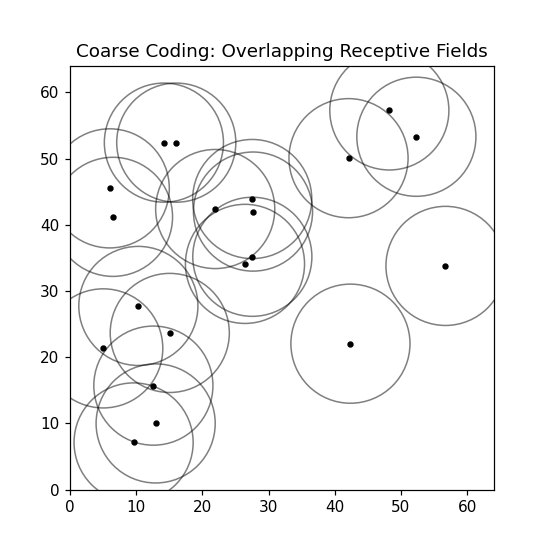

In [8]:
# ============================================================
# 7. STANDALONE EDUCATIONAL VISUALIZATION: coarse coding schematic
# ------------------------------------------------------------
# Shows how overlapping receptive fields (as used in the encoder's
# conv layers) cover the image plane -- a direct visual analogue of
# Figure 3 in the paper.
# ============================================================
fig_cc, ax_cc = plt.subplots(figsize=(5, 5))
fig_cc.patch.set_facecolor("white")
ax_cc.set_facecolor("white")
np.random.seed(1)
centers = np.random.uniform(5, 59, size=(20, 2))
for (cx, cy) in centers:
    circ = plt.Circle((cx, cy), 9, fill=False, color="black", alpha=0.5)
    ax_cc.add_patch(circ)
ax_cc.scatter(centers[:, 0], centers[:, 1], color="black", s=10)
ax_cc.set_xlim(0, 64)
ax_cc.set_ylim(0, 64)
ax_cc.set_title("Coarse Coding: Overlapping Receptive Fields", color="black")
ax_cc.set_aspect("equal")
ax_cc.tick_params(colors="black")
for spine in ax_cc.spines.values():
    spine.set_color("black")
render_inline(fig_cc)

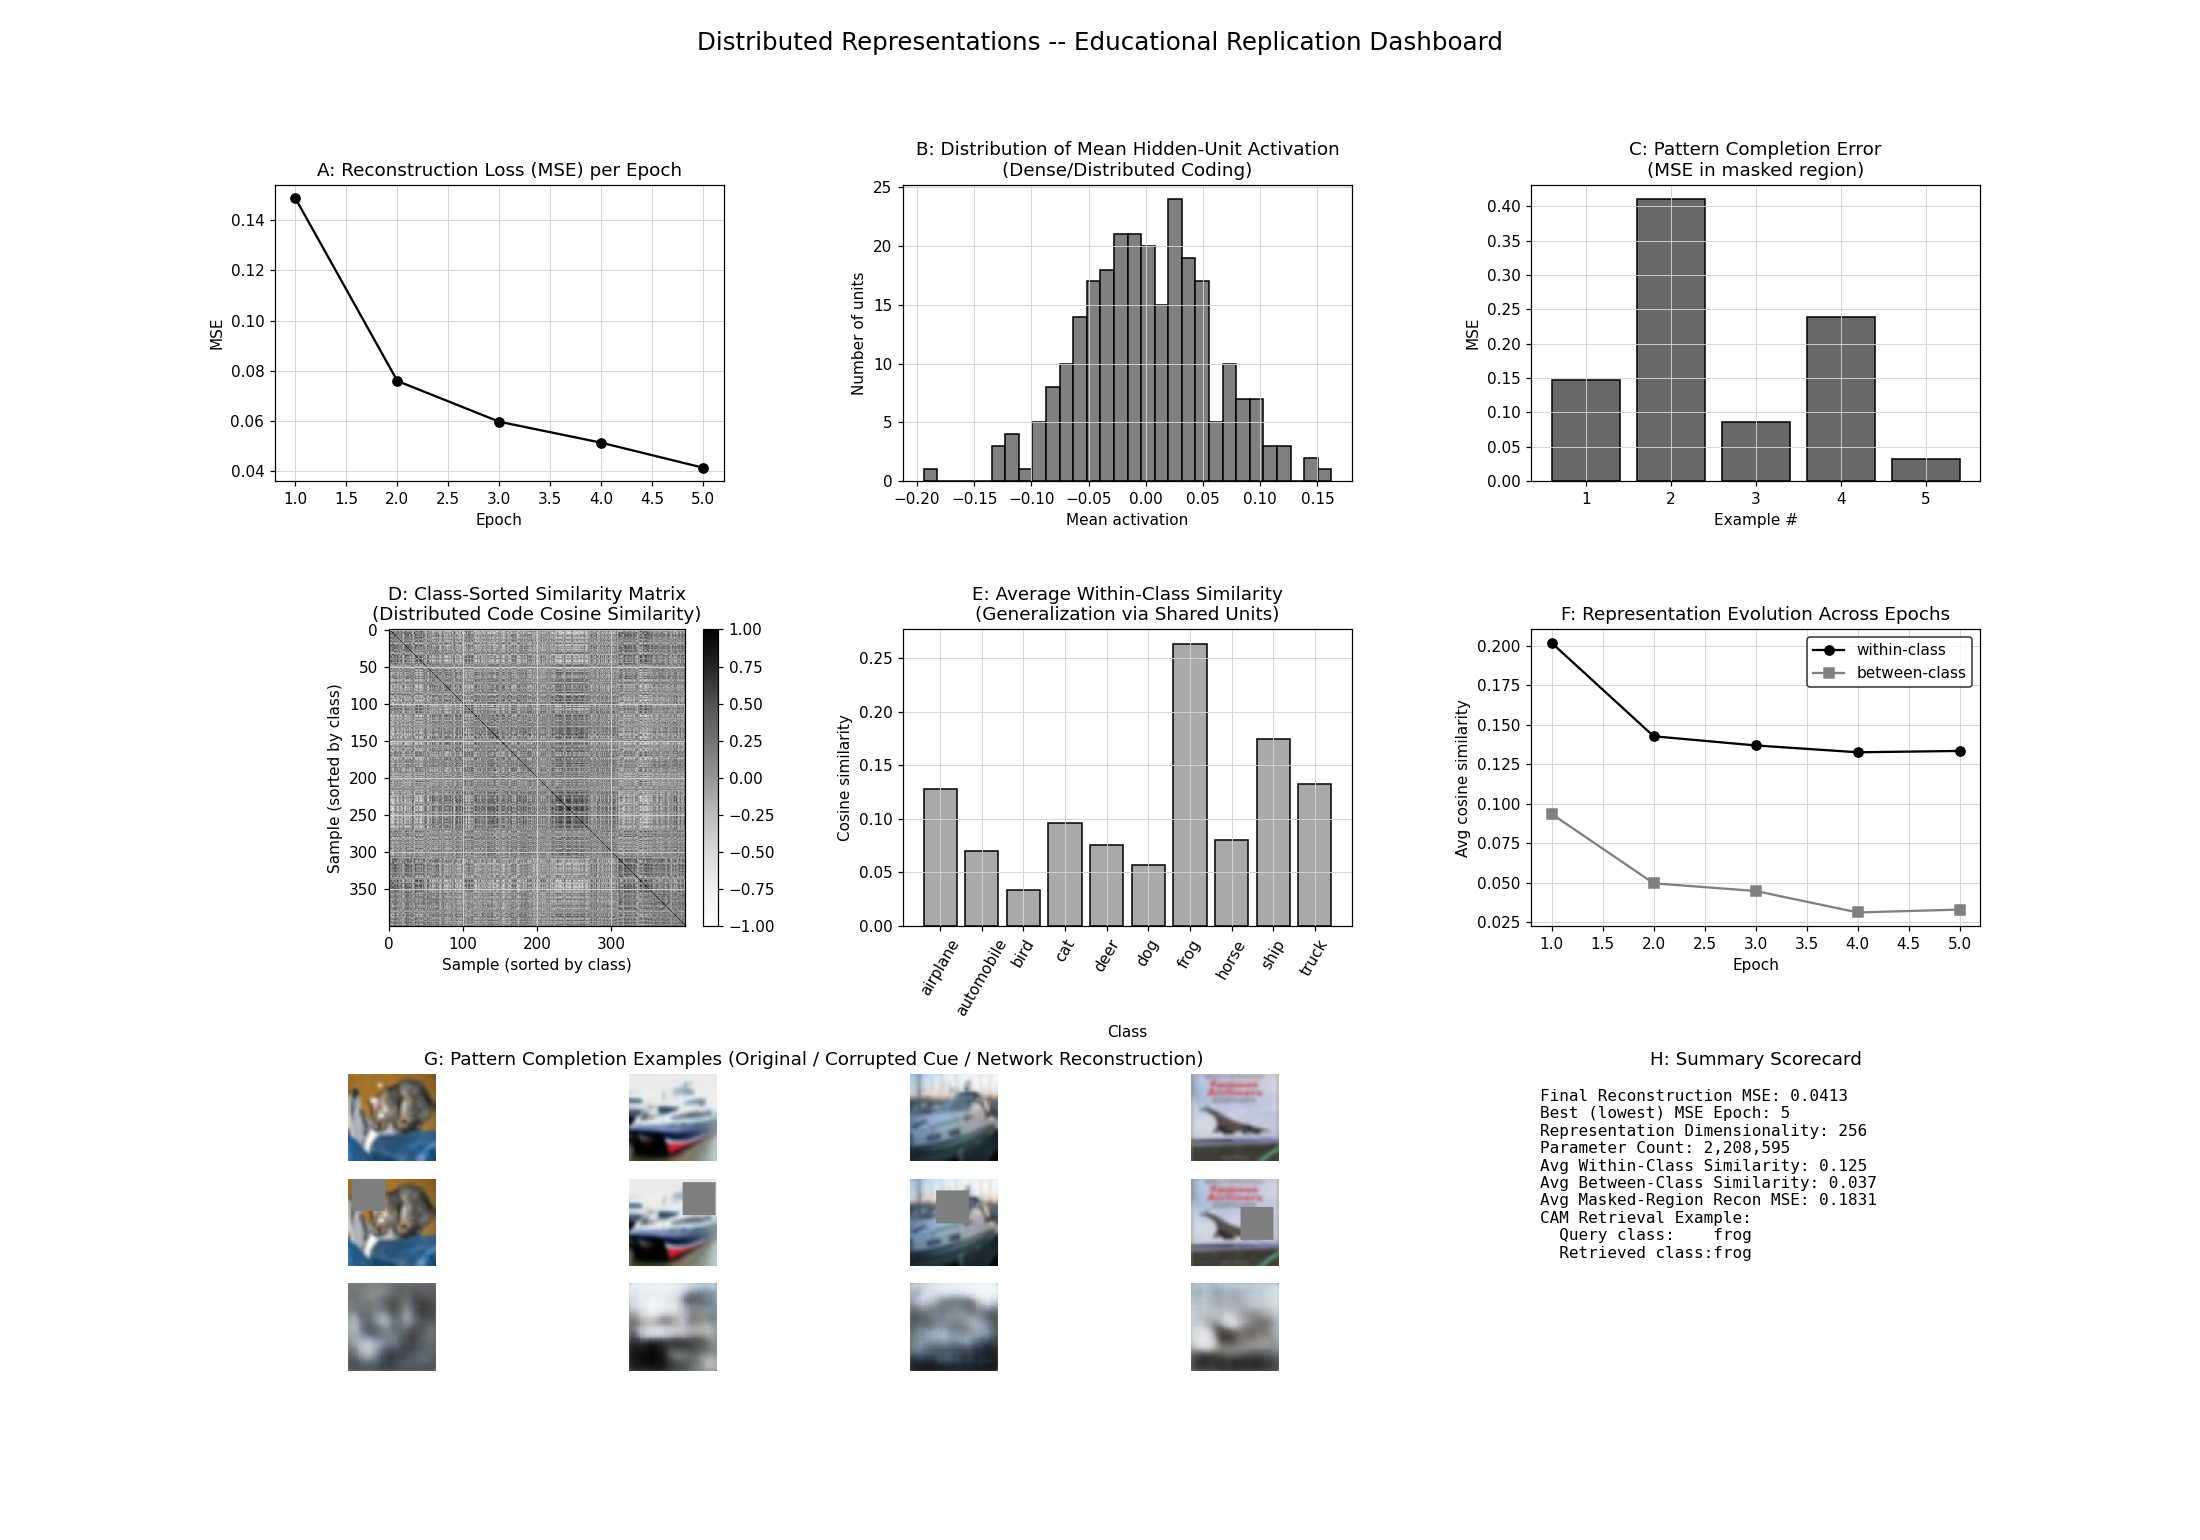

In [9]:
# ============================================================
# 8. FINAL DASHBOARD (GridSpec, 8 labeled panels A-H)
# ============================================================
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor("white")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

def style_axis(ax):
    ax.set_facecolor("white")
    ax.tick_params(colors="black")
    for spine in ax.spines.values():
        spine.set_color("black")
    ax.grid(True, color="lightgray", linewidth=0.6)
    ax.title.set_color("black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")

# --- Panel A: Training objective (reconstruction loss) ---
axA = fig.add_subplot(gs[0, 0])
style_axis(axA)
axA.plot(range(1, EPOCHS+1), train_losses, marker="o", color="black")
axA.set_title("A: Reconstruction Loss (MSE) per Epoch")
axA.set_xlabel("Epoch")
axA.set_ylabel("MSE")

# --- Panel B: Distributed coding statistics ---
axB = fig.add_subplot(gs[0, 1])
style_axis(axB)
axB.hist(mean_unit_activation, bins=30, color="gray", edgecolor="black")
axB.set_title("B: Distribution of Mean Hidden-Unit Activation\n(Dense/Distributed Coding)")
axB.set_xlabel("Mean activation")
axB.set_ylabel("Number of units")

# --- Panel C: Pattern completion quality ---
axC = fig.add_subplot(gs[0, 2])
style_axis(axC)
axC.bar(range(1, n_examples+1), masked_mse_list, color="dimgray", edgecolor="black")
axC.set_title("C: Pattern Completion Error\n(MSE in masked region)")
axC.set_xlabel("Example #")
axC.set_ylabel("MSE")

# --- Panel D: Class similarity matrix (block-diagonal structure) ---
axD = fig.add_subplot(gs[1, 0])
style_axis(axD)
im = axD.imshow(sim_matrix_sorted.numpy(), cmap="Greys", vmin=-1, vmax=1)
axD.set_title("D: Class-Sorted Similarity Matrix\n(Distributed Code Cosine Similarity)")
axD.set_xlabel("Sample (sorted by class)")
axD.set_ylabel("Sample (sorted by class)")
fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)

# --- Panel E: Per-class within-class similarity ---
axE = fig.add_subplot(gs[1, 1])
style_axis(axE)
axE.bar([CLASS_NAMES[c] for c in per_class_sim.keys()],
        list(per_class_sim.values()), color="darkgray", edgecolor="black")
axE.set_title("E: Average Within-Class Similarity\n(Generalization via Shared Units)")
axE.set_xlabel("Class")
axE.set_ylabel("Cosine similarity")
axE.tick_params(axis="x", rotation=60)

# --- Panel F: Representation evolution across epochs ---
axF = fig.add_subplot(gs[1, 2])
style_axis(axF)
within_vals = [w for w, b in epoch_within_class_sim]
between_vals = [b for w, b in epoch_within_class_sim]
axF.plot(range(1, EPOCHS+1), within_vals, marker="o", color="black", label="within-class")
axF.plot(range(1, EPOCHS+1), between_vals, marker="s", color="gray", label="between-class")
axF.set_title("F: Representation Evolution Across Epochs")
axF.set_xlabel("Epoch")
axF.set_ylabel("Avg cosine similarity")
axF.legend(facecolor="white", edgecolor="black", labelcolor="black")

# --- Panel G: Qualitative pattern completion examples ---
axG = fig.add_subplot(gs[2, :2])
axG.set_facecolor("white")
axG.axis("off")
axG.set_title("G: Pattern Completion Examples "
              "(Original / Corrupted Cue / Network Reconstruction)", color="black")
n_show = 4
grid_h = 3
for j in range(n_show):
    for row, imgset, name in zip(range(grid_h),
                                  [originals, corrupted_list, reconstructed_list],
                                  ["orig", "cue", "recon"]):
        sub_ax = fig.add_subplot(gs[2, :2].subgridspec(grid_h, n_show)[row, j])
        sub_ax.imshow(denorm(imgset[j]))
        sub_ax.axis("off")
        if j == 0:
            sub_ax.set_ylabel(name, color="black")

# --- Panel H: Summary scorecard ---
axH = fig.add_subplot(gs[2, 2])
axH.set_facecolor("white")
axH.axis("off")
axH.set_title("H: Summary Scorecard", color="black")

scorecard_text = (
    f"Final Reconstruction MSE: {train_losses[-1]:.4f}\n"
    f"Best (lowest) MSE Epoch: {int(np.argmin(train_losses))+1}\n"
    f"Representation Dimensionality: {DIST_DIM}\n"
    f"Parameter Count: {n_params:,}\n"
    f"Avg Within-Class Similarity: {within_final:.3f}\n"
    f"Avg Between-Class Similarity: {between_final:.3f}\n"
    f"Avg Masked-Region Recon MSE: {np.mean(masked_mse_list):.4f}\n"
    f"CAM Retrieval Example:\n"
    f"  Query class:    {CLASS_NAMES[gallery_labels[query_idx]]}\n"
    f"  Retrieved class:{CLASS_NAMES[gallery_labels[best_match_idx]]}"
)
axH.text(0.02, 0.95, scorecard_text, transform=axH.transAxes,
         fontsize=10.5, color="black", va="top", family="monospace")

fig.suptitle("Distributed Representations -- Educational Replication Dashboard",
             fontsize=16, color="black", y=0.98)

render_inline(fig)

# Analysis of Experimental Results: Educational Replication Dashboard

## Panel A: Reconstruction Loss (MSE) per Epoch

### Overview
Tracks the mean-squared reconstruction error of the autoencoder across 5 training epochs, serving as the primary optimization objective for learning the distributed hidden-code representation.

### Key Findings
MSE decreases monotonically from approximately 0.148 at epoch 1 to 0.041 at epoch 5, with the steepest drop occurring between epochs 1 and 2 (0.148 → 0.076), followed by diminishing returns.

### Discussion
The rapid initial decrease followed by a flattening curve is typical of gradient-based optimization on a small, low-complexity dataset (2,000 images) and indicates the network is converging toward a stable reconstruction solution rather than overfitting noise. Given the paper's emphasis on distributed codes supporting pattern reconstruction, this curve provides basic evidence that the bottleneck representation retains sufficient information to regenerate input images, consistent with the "memory as inference" framing.

### Limitations
Only five epochs were run, so it is unclear whether the loss has fully converged or would continue improving. No validation curve is shown, so overfitting cannot be ruled out despite the small dataset size.

---

## Panel B: Distribution of Mean Hidden-Unit Activation

### Overview
A histogram of the average activation value of each of the 256 hidden units across the test set, intended to illustrate whether the learned code is "distributed" (many units moderately active) rather than "local" (few units highly active, most near zero).

### Key Findings
Activations are approximately unimodal and roughly symmetric around zero, spanning a range of about −0.2 to 0.15, with the bulk of units clustered near 0.

### Discussion
This bell-shaped, non-sparse distribution supports the paper's central claim that information is spread across many units rather than concentrated in a few dedicated "grandmother cells." However, the tight clustering near zero also suggests relatively low average activation magnitude, meaning many units may be contributing only weakly to any given representation—raising a question about how "coarse" versus "diffuse" the coding actually is.

### Limitations
Mean activation alone does not confirm distributed coding; a proper verification would require examining per-image activation patterns (e.g., how many units are strongly active per sample) rather than only the population-level mean, since a low-variance, near-zero-centered histogram could also result from underutilized capacity.

---

## Panel C: Pattern Completion Error (Masked-Region MSE)

### Overview
Reports reconstruction MSE restricted to the artificially masked (zeroed) region of five test images, evaluating the network's ability to infer missing content from a distributed code—directly analogous to the paper's discussion of content-addressable, cue-based recall.

### Key Findings
Per-example masked-region MSE varies considerably, from about 0.03–0.09 (examples 3 and 5) to over 0.4 (example 2), indicating inconsistent completion quality across instances.

### Discussion
The high variance across examples suggests that pattern completion quality is strongly content-dependent: images with more typical, class-consistent structure appear to be completed more accurately, while atypical or high-contrast patches (e.g., example 2) are harder to infer. This is consistent with the paper's argument that distributed reconstruction relies on regularities learned from the training set—atypical inputs violate more "microinferences" and are completed less accurately.

### Limitations
With only five examples, this result is qualitative rather than statistically robust; no comparison to a baseline (e.g., mean-pixel fill or nearest-neighbor completion) is provided to contextualize whether the observed errors are meaningfully low.

---

## Panel D: Class-Sorted Similarity Matrix

### Overview
Visualizes cosine similarity between distributed codes for all test images, sorted by class label, to assess whether same-class samples produce more similar (higher-similarity) codes than different-class samples—evidence for automatic generalization through shared representational structure.

### Key Findings
The matrix shows a faint diagonal band of higher similarity near the identity line but no strong visible block-diagonal structure corresponding to class boundaries; most off-diagonal similarity values appear low and relatively uniform (light gray).

### Discussion
The weak block structure indicates that class identity is only mildly reflected in the learned distributed code, which is expected given that the network was trained purely for pixel-level reconstruction without any class-supervised objective. This suggests the representation captures low-level visual regularities (color, texture, layout) rather than semantic/categorical structure, a reasonable outcome for an unsupervised autoencoder but a limited demonstration of the paper's "generalization across similar concepts" claim.

### Limitations
Visual inspection of a similarity heatmap is a coarse diagnostic; quantitative clustering metrics (e.g., silhouette score, class-conditional variance ratio) would provide stronger evidence. The absence of clear block structure may also stem from the small dataset size (400 test images) limiting reliable class-level statistics.

---

## Panel E: Average Within-Class Similarity

### Overview
Quantifies, per class, the mean cosine similarity between distributed codes of same-class test images, offering a more granular view of representational clustering than Panel D.

### Key Findings
Within-class similarity varies substantially by class: "frog" shows the highest similarity (~0.26), followed by "ship" (~0.17) and "truck" (~0.13), while "bird" (~0.03) and "automobile" (~0.07) show markedly lower similarity.

### Discussion
The disparity across classes likely reflects differences in visual homogeneity within each class in CIFAR-10—for instance, ships and frogs may share consistent background/color cues (water, green tones), producing more similar codes, whereas birds and automobiles vary widely in pose, viewpoint, and background, yielding more heterogeneous codes. This pattern is consistent with the paper's account that generalization strength depends on the degree of underlying regularity shared among instances of a category, rather than being uniform across all concepts.

### Limitations
With roughly 40 test images per class, per-class similarity estimates are subject to considerable sampling variance; the observed differences may partly reflect small-sample artifacts in addition to genuine visual heterogeneity.

---

## Panel F: Representation Evolution Across Epochs

### Overview
Tracks average within-class and between-class code similarity over training epochs, illustrating how the representation's discriminative structure develops during learning.

### Key Findings
Both within-class and between-class similarity decline sharply from epoch 1 to epoch 2 and then plateau; within-class similarity consistently remains above between-class similarity throughout training (e.g., ~0.13 vs. ~0.03 by epoch 5).

### Discussion
The persistent gap between within- and between-class similarity, despite the absence of any label supervision, indicates that the reconstruction objective alone induces some class-correlated structure in the hidden code—an emergent form of generalization consistent with the paper's claim that shared visual regularities are captured automatically by distributed representations. The early decline in both curves likely reflects the code moving from a poorly structured (high-similarity, low-information) initialization toward a more differentiated, informative embedding space as training proceeds.

### Limitations
The plateau after epoch 2 suggests the representation may have stabilized prematurely due to the short (5-epoch) training schedule; longer training might alter this gap further. The two-batch subset used for early-epoch statistics may introduce measurement noise not fully separable from genuine representational change.

---

## Panel G: Pattern Completion Examples (Qualitative)

### Overview
Displays four qualitative triplets (original, corrupted cue, reconstruction) to visually assess pattern completion, complementing the quantitative Panel C metric.

### Key Findings
Reconstructions are visibly blurred but recover coarse color, shape, and layout information consistent with the original image (e.g., ship silhouette, general animal shape); fine details and textures are largely lost.

### Discussion
The blurred but structurally plausible reconstructions are characteristic of small-bottleneck, MSE-trained autoencoders, which tend to average over plausible pixel values rather than hallucinate sharp detail. This behavior illustrates the paper's point that distributed representations support approximate, "good but not necessarily optimal" pattern completion rather than exact recall—qualitatively supporting the memory-as-constraint-satisfaction analogy, albeit in a much simplified, non-symbolic form.

### Limitations
Only four qualitative examples are shown, which is insufficient for generalizable conclusions; blur is also a well-known artifact of MSE loss in autoencoders unrelated to the specific theoretical claims of the paper, so the qualitative match to "pattern completion" should be interpreted cautiously as an analogy rather than a rigorous replication.

---

## Panel H: Summary Scorecard

### Overview
Consolidates key quantitative outcomes: final reconstruction MSE (0.0413), best epoch (5), representation dimensionality (256), parameter count (~2.2M), average within/between-class similarity (0.125 / 0.037), average masked-region MSE (0.183), and a content-addressable retrieval example (query and retrieved class both "frog").

### Key Findings
The correct-class retrieval match (frog → frog) in the nearest-neighbor content-addressable memory demonstration, combined with a nontrivial within/between-class similarity gap (0.125 vs. 0.037), suggests the learned distributed code carries some class-relevant signal despite unsupervised training.

### Discussion
Collectively, these summary statistics offer converging, modest evidence for the paper's core claims: reconstruction improves with training (Panel A), the code is non-local/distributed (Panel B), and same-class similarity structure emerges without explicit supervision (Panels D–F), with a successful qualitative retrieval example (Panel H) illustrating content-addressability. However, the effect sizes are modest (e.g., a 0.125 vs. 0.037 similarity gap) rather than strong, reflecting the intentionally simplified educational scope of the implementation.

### Limitations
A single successful retrieval example is anecdotal and does not establish retrieval accuracy at scale; no aggregate retrieval accuracy metric (e.g., top-1/top-5 class-match rate across many queries) is reported, which would be necessary to substantiate the content-addressable memory claim more rigorously. The overall results should be interpreted as an illustrative, small-scale pedagogical demonstration rather than a faithful quantitative validation of the original 1986 theoretical framework.

# Related Work Cited in "Distributed Representations"

Note: The provided excerpt of this chapter does not include a formal reference list/bibliography; only in-text citations appear. Titles, exact venues, and years for some entries are therefore not fully determinable from the supplied text and are marked "Not specified in text" where applicable.

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Norman, D. A. & Bobrow, D. G. | 1979 | Not specified in text | Not specified in text | Cited for the observation that people can recall items from partial descriptions, motivating the paper's "memory as inference" framing of content-addressable memory. |
| Anderson, J. A. | 1977 | Not specified in text | Not specified in text | Cited as providing illustrations that connections among simple processing units can support many stored patterns simultaneously, supporting the paper's distributed memory model. |
| Hinton, G. E. | 1981a | Not specified in text | Not specified in text | Cited multiple times as the source of a computer simulation implementing the theory of generalization via distributed representations, and for a gating mechanism for role/relationship binding; foundational to the paper's proposed mechanisms. |
| Bartlett, F. C. | 1932 | Not specified in text | Not specified in text | Cited for classic evidence on the reconstructive nature of human memory, supporting the paper's claim that distributed representations naturally blur genuine recall and plausible reconstruction. |
| Neisser, U. | 1981 | Not specified in text | Not specified in text | Cited alongside Bartlett (1932) as further evidence for the reconstructive character of human memory. |
| Hopfield, J. J. | 1984 | Not specified in text | Not specified in text | Cited as providing an alternative approach using units with continuous activations for settling on stable patterns, relevant to the paper's discussion of stochastic/statistical-mechanics approaches to memory retrieval. |
| Hinton, G. E. & Anderson, J. A. (Eds.) | 1981 | Not specified in text | Not specified in text | Cited as a source of variations on distributed memory models, supporting the paper's discussion of interference and statistical reasoning in weight modification. |
| Collins, A. M. & Loftus, E. F. | 1975 | Not specified in text | Not specified in text | Cited as an example of spreading-activation mechanisms in local/semantic-network models, contrasted with the automatic generalization inherent to distributed representations. |
| Quillian, M. R. | 1968 | Not specified in text | Not specified in text | Cited alongside Collins & Loftus as an originator of spreading-activation semantic network models, used as a comparison point for local representation schemes. |
| Fahlman, S. E. | 1979 | Not specified in text | Not specified in text | Cited as a variation of spreading-activation approaches in local representation schemes. |
| Fahlman, S. E. | 1980 | Not specified in text | Not specified in text | Cited for a scheme using intermediate unit layers to implement indirect connections between concept-units in local representation systems, discussed as an inefficient alternative to distributed representations. |
| Levin, J. A. | 1976 | Not specified in text | Not specified in text | Cited as another variation of spreading-activation mechanisms in local semantic network models. |
| McClelland, J. L. | 1981 | Not specified in text | Not specified in text | Cited repeatedly as a generalization and retrieval model whose properties (pattern-based generalization) blur the local/distributed distinction, directly relevant to this paper's core argument. |
| Feldman, J. A. | 1982 | Not specified in text | Not specified in text | Cited alongside Fahlman (1980) for schemes using layered intermediate units to connect concept-nodes, used as a comparison for the inefficiency of local encoding schemes for new concepts. |
| Luria, A. R. | 1973 | Not specified in text | Not specified in text | Cited regarding evidence for functional localization in the brain, used to clarify that distributed representations are compatible with (not contradictory to) localized brain modules. |
| Minsky, M. & Papert, S. | 1969 | Not specified in text | Not specified in text | Cited for the classic exclusive-or (XOR) problem, used as an example motivating the necessity of conjunctive encoding in distributed representation schemes. |
| Willshaw, D. J. | 1981 | Not specified in text | Not specified in text | Cited as having analyzed models structurally similar to the paper's word-set/sememe network, and for proposing veto-based schemes to improve robustness to missing connections. |
| Wood, C. C. | 1978 | Not specified in text | Not specified in text | Cited for observing similar graceful-degradation effects (error rise rather than total word loss upon unit removal) in other distributed models, corroborating this paper's simulation results. |
| Coltheart, M., Patterson, K., & Marshall, J. C. (Eds.) | 1980 | Not specified in text | Not specified in text | Cited as the source on acquired/deep dyslexia, used to draw a psychological parallel to the semantic substitution errors observed in the paper's damaged network simulation. |
| Kawamoto, A. H. & Anderson, J. A. | 1984 | Not specified in text | Not specified in text | Cited regarding competitive interactions at the sememe level suppressing alternate word meanings, supporting the paper's account of ambiguous-word resolution (e.g., "bank"). |
| Newell, A. | 1980 | Not specified in text | Not specified in text | Cited as the source of the "sequential symbol processing" tenet (focusing on and expanding parts of a structure), which the paper reinterprets in terms of successive states of a distributed network. |